# Predictive Maintenance - Failure Classification
## AI4I 2020 Manufacturing Dataset

This notebook builds and compares classification models to predict 
machine failure based on sensor readings. It follows up on the 
exploratory analysis from the companion EDA notebook https://github.com/Kseniia-Kud/predictive-maintenance-eda/blob/main/Predictive%20Maintenance.ipynb.

**Goal:** Predict `Machine failure` (binary classification) using 
sensor data: Air temperature, Process temperature, Rotational 
speed, Torque, and Tool wear.

**Challenge:** The dataset is highly imbalanced (3.39% failure rate), 
requiring careful model evaluation beyond simple accuracy.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load & Prepare Data

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print(df.shape)
print(df.isnull().sum())

(10000, 14)
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


### 3. Train/Test Split (stratified)

Based on the EDA findings, we use the five core sensor readings 
as features, excluding ID columns and failure-type indicators 
(which would leak the target).

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X = df[['Air temperature [K]', 'Process temperature [K]', 
        'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify=y)

### 4. Baseline Model - Logistic Regression

In [4]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))  
print(precision_score(y_test, y_pred))  
print(recall_score(y_test, y_pred))    
print(f1_score(y_test, y_pred))   

0.821
0.13930348258706468
0.8235294117647058
0.23829787234042554


### 5. Random Forest Model

In [5]:
from sklearn.ensemble import RandomForestClassifier

model_r = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model_r.fit(X_train, y_train)
y_pred = model_r.predict(X_test)
print(accuracy_score(y_test, y_pred))   
print(precision_score(y_test, y_pred))  
print(recall_score(y_test, y_pred))     
print(f1_score(y_test, y_pred))

0.983
0.8863636363636364
0.5735294117647058
0.6964285714285714


### 6. Model Comparison

| Model | Recall | Precision | F1 (CV mean) |
|-------|--------|-----------|--------------|
| Logistic Regression | 0.824 | 0.139 | 0.235 |
| Random Forest | 0.570 | 0.886 | 0.652 |

**Finding:** Random Forest significantly outperforms Logistic 
Regression in F1-score (0.652 vs 0.235) and Precision (0.886 vs 
0.139), making it the stronger overall model. However, Logistic 
Regression achieves higher Recall (0.824 vs 0.570), meaning it 
catches more true failures at the cost of many more false alarms.

The choice between models depends on business priorities:
- If missing a failure is extremely costly (safety risk, major 
  downtime) → Logistic Regression's higher recall may be preferred
- If engineers are overwhelmed by false alarms → Random Forest's 
  higher precision makes it more practical

Given Random Forest's superior F1-score and the ability to tune 
its threshold (Section 8), it is selected as the primary model 
for this analysis.

### 7. Feature Importance

In [7]:
importances = model_r.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance_df)

                   feature  importance
3              Torque [Nm]    0.320186
2   Rotational speed [rpm]    0.313260
4          Tool wear [min]    0.215002
0      Air temperature [K]    0.092968
1  Process temperature [K]    0.058584


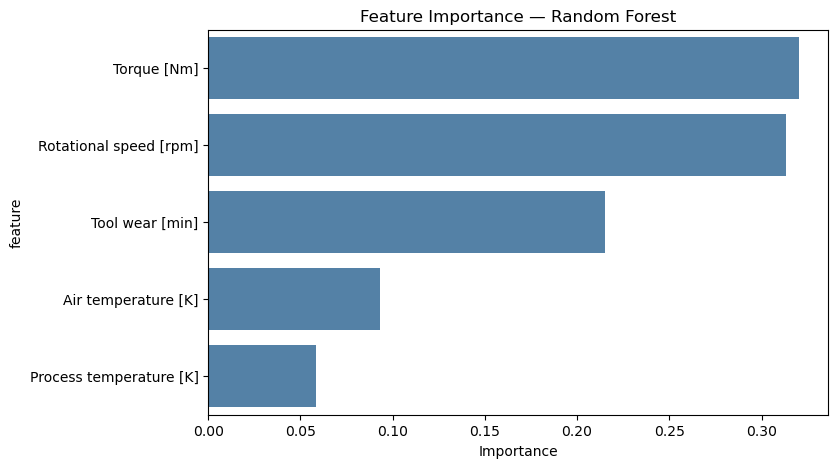

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance_df, x='importance', y='feature', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.show()

**Finding:** Torque (32.0%) and Rotational Speed (31.3%) are the 
two most important predictors of machine failure, together 
accounting for over 60% of the model's decision-making. Tool Wear 
follows at 21.5%. Temperature-related features (Air and Process 
temperature) contribute the least, at under 16% combined.

This aligns closely with the findings from the EDA notebook, where 
Torque showed the strongest correlation with failure (0.19) and 
96% of Torque outliers corresponded to actual failures. The model's 
feature importance confirms these visual and statistical 
observations from the exploratory analysis.

### 8. Threshold Tuning

In [11]:
# Get probabilities instead of hard predictions
y_proba = model_r.predict_proba(X_test)[:, 1]

# Compare default threshold (0.5) vs custom threshold (0.3)
threshold = 0.3
y_pred_custom = (y_proba > threshold).astype(int)

print(f"Default (0.5) — Recall: {recall_score(y_test, y_pred):.3f}, Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Custom (0.3)  — Recall: {recall_score(y_test, y_pred_custom):.3f}, Precision: {precision_score(y_test, y_pred_custom):.3f}")

Default (0.5) — Recall: 0.574, Precision: 0.886
Custom (0.3)  — Recall: 0.750, Precision: 0.823


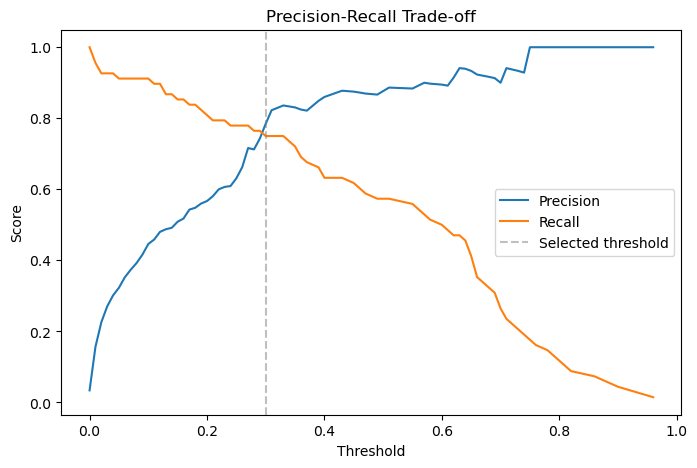

In [12]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.3, color='gray', linestyle='--', alpha=0.5, label='Selected threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off')
plt.legend()
plt.show()

By default, classifiers use a 0.5 probability threshold to decide 
between classes. Lowering this threshold makes the model more 
sensitive to the positive class (failure), trading some precision 
for higher recall.

| Threshold | Recall | Precision |
|-----------|--------|-----------|
| 0.5 (default) | 0.574 | 0.886 |
| 0.3 (tuned) | 0.750 | 0.823 |

**Finding:** Lowering the threshold from 0.5 to 0.3 improved Recall 
by 18 percentage points (0.57 → 0.75) while only reducing Precision 
by 6 points (0.886 → 0.823). 

This represents a significantly better trade-off for predictive 
maintenance, where the cost of missing a real failure (unplanned 
downtime, safety risk) typically far outweighs the cost of an 
unnecessary inspection. The threshold of 0.3 is recommended for 
production use.

### 9. Cross-Validation

In [14]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
lr_scores = cross_val_score(LogisticRegression(class_weight='balanced'), 
                              X, y, cv=cv, scoring='f1')

# Random Forest
rf_scores = cross_val_score(RandomForestClassifier(n_estimators=100, 
                              class_weight='balanced', random_state=42), 
                              X, y, cv=cv, scoring='f1')

print(f"Logistic Regression — mean F1: {lr_scores.mean():.3f}, std: {lr_scores.std():.3f}")
print(f"Random Forest       — mean F1: {rf_scores.mean():.3f}, std: {rf_scores.std():.3f}")

Logistic Regression — mean F1: 0.235, std: 0.007
Random Forest       — mean F1: 0.652, std: 0.023


To ensure the model comparison is robust and not dependent on a 
single lucky/unlucky train-test split, 5-fold stratified 
cross-validation was performed on both models.

| Model | F1 (mean) | F1 (std) |
|-------|-----------|----------|
| Logistic Regression | 0.235 | 0.007 |
| Random Forest | 0.652 | 0.023 |

**Finding:** Random Forest consistently outperforms Logistic 
Regression across all folds, with a low standard deviation (0.023), 
confirming that its strong performance is stable and not due to 
chance. This validates Random Forest as the more reliable model 
for this task.

## 10. Key Findings & Conclusions

### Model Performance
Two classification models were built and compared to predict 
machine failure:

- **Logistic Regression** achieved high Recall (0.824) but very
  low Precision (0.139), generating excessive false alarms
- **Random Forest** achieved a much stronger balance — F1-score 
  of 0.652 (vs 0.235), driven by significantly higher Precision 
  (0.886)
- Cross-validation confirmed Random Forest's performance is stable 
  and consistent (std = 0.023), not the result of a lucky split

### Feature Importance
- **Torque** (32.0%) and **Rotational Speed** (31.3%) are the 
  strongest predictors of failure, confirming the correlation 
  patterns identified in the EDA notebook
- **Tool Wear** (21.5%) is the third most important feature
- Temperature-related features contribute the least (under 16% 
  combined)

### Threshold Optimization
- Lowering the classification threshold from 0.5 to 0.3 improved 
  Recall from 0.57 to 0.75, with only a minor drop in Precision 
  (0.886 → 0.823)
- This adjustment better reflects the real business cost of 
  predictive maintenance, where missing a failure is more 
  expensive than an unnecessary inspection

### Final Recommendation
**Random Forest with a 0.3 classification threshold** is recommended 
for production deployment. This configuration catches 75% of real 
failures while maintaining 82% precision, offering the best balance 
between operational cost and safety risk.

### Next Steps
- Experiment with additional models (XGBoost, Gradient Boosting)
- Apply SMOTE for further handling of class imbalance
- Engineer new features (e.g. interaction between Torque and 
  Rotational Speed, given their strong negative correlation)
- Deploy model with a monitoring pipeline to track performance 
  drift over time